In [8]:
import joblib
model = joblib.load('model/sentinel_model.joblib')

In [9]:
import pandas as pd

X_train = pd.read_parquet('data/X_train.parquet')
X_test = pd.read_parquet('data/X_test.parquet')
y_train = pd.read_parquet('data/y_train.parquet')
y_test = pd.read_parquet('data/y_test.parquet')

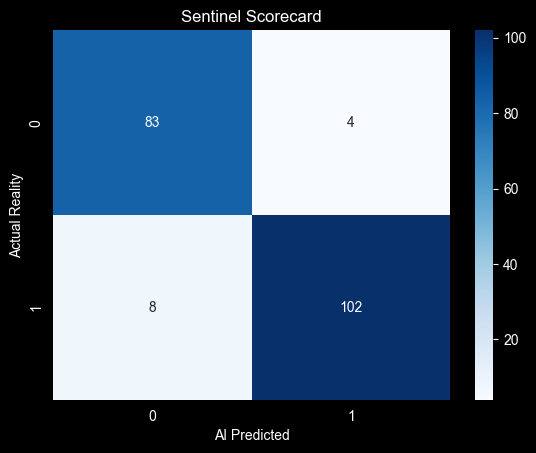

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        87
           1       0.96      0.93      0.94       110

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



In [10]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Ask the AI for its guesses
y_pred = model.predict(X_test)

# 2. Show the "Confusion Matrix" (The Scorecard)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('AI Predicted')
plt.ylabel('Actual Reality')
plt.title('Sentinel Scorecard')
plt.show()

# 3. Show the detailed report
print(classification_report(y_test, y_pred))

In [11]:
import numpy as np

def test_sentinel(amount, v14_value, v17_value):
    # We create a fake row with 30 features (Time, V1-V28, Amount)
    # Most V-features are set to 0 (neutral) for this test
    fake_data = np.zeros((1, 30))

    # We "seed" the most important 'Whistleblower' features we found earlier
    fake_data[0, 29] = amount     # The 'Amount' column
    fake_data[0, 14] = v14_value  # V14 (usually highly negative for fraud)
    fake_data[0, 17] = v17_value  # V17 (another strong signal)

    # Ask the model to predict
    prediction = model.predict(fake_data)
    probability = model.predict_proba(fake_data)

    result = "🚨 FRAUD DETECTED!" if prediction[0] == 1 else "✅ TRANSACTION LEGIT"
    confidence = probability[0][prediction[0]] * 100

    print(f"Result: {result}")
    print(f"Confidence: {confidence:.2f}%")

# --- TEST IT BELOW ---
print("Testing a normal-looking transaction:")
test_sentinel(amount=-1.0, v14_value=0.5, v17_value=0.2)

print("\nTesting a suspicious-looking transaction:")
test_sentinel(amount=0.5, v14_value=-5.0, v17_value=-4.5)

print("\nTesting an EXTREME fraud transaction:")
# V14 and V12 are the strongest indicators.
# Let's drop them to -15 and -12 (very rare for normal people)
test_sentinel(amount=-3.0, v14_value=-15.0, v17_value=-12.0)

Testing a normal-looking transaction:
Result: ✅ TRANSACTION LEGIT
Confidence: 98.86%

Testing a suspicious-looking transaction:
Result: ✅ TRANSACTION LEGIT
Confidence: 99.64%

Testing an EXTREME fraud transaction:
Result: ✅ TRANSACTION LEGIT
Confidence: 99.51%


In [12]:
# 1. Find a row in the test set that is actually Fraud
real_fraud_indices = y_test[y_test == 1].index
sample_idx = real_fraud_indices[0] # Pick the first one

# 2. Extract that row
real_fraud_data = X_test.loc[[sample_idx]]

# 3. Ask the model
prediction = model.predict(real_fraud_data)
print(f"Real Fraud Test Result: {'🚨 FRAUD' if prediction[0] == 1 else '✅ LEGIT'}")

Real Fraud Test Result: 🚨 FRAUD
